# **Latent Diffusion Model**

# **Dhruv's Contribution**

Loading Dependencies

In [1]:
!pip install torch torchvision torchaudio
!pip install torchmetrics[image]
!pip install diffusers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 107.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 37.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [11]:
!file balanced_labeled_photos.zip

balanced_labeled_photos.zip: Zip archive data, at least v2.0 to extract, compression method=store


Loading Data

In [12]:
import shutil
import os

zip_path = "/content/balanced_labeled_photos.zip"
extract_path = "balanced_labeled_photos"

if not os.path.exists(extract_path):
    shutil.unpack_archive(zip_path, extract_path)
    print("Dataset extracted successfully.")
else:
    print("Dataset already extracted.")

Dataset extracted successfully.


In [14]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = datasets.ImageFolder(root='balanced_labeled_photos', transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [22]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Encoding

In [25]:
# Instantiate models and move them to device
encoder = Encoder().to(device)
decoder = Decoder().to(device)
denoiser = UNet().to(device)

In [26]:
# VAE-style Encoder
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(256, 512, 4, 2, 1), nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)

# Decoder
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh()
        )
    def forward(self, x):
        return self.net(x)

# Simplified UNet denoiser
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(512, 512, 3, 1, 1), nn.ReLU(),
            nn.Conv2d(512, 512, 3, 1, 1), nn.ReLU()
        )
    def forward(self, x, t):
        return self.net(x)

In [28]:
loss_fn = nn.MSELoss()

In [30]:
import torch.optim as optim

# Combine parameters from encoder, decoder, and denoiser
optimizer = optim.Adam(
    list(encoder.parameters()) +
    list(decoder.parameters()) +
    list(denoiser.parameters()),
    lr=1e-4
)

Model Building

In [35]:
import time
import random
from tqdm import tqdm
from torch.utils.data import Subset, DataLoader

subset_size = 10000
indices = random.sample(range(len(dataset)), subset_size)
subset = Subset(dataset, indices)

dataloader = DataLoader(subset, batch_size=64, shuffle=True)

#Training loop
for epoch in range(100):
    start_time = time.time()
    total_loss = 0.0
    total_recon_loss = 0.0
    total_denoise_loss = 0.0

    loop = tqdm(dataloader, desc=f"Epoch {epoch+1}", leave=False)
    max_steps = 200

    for step, (imgs, _) in enumerate(loop):
        if step >= max_steps:
            break

        imgs = imgs.to(device)
        latents = encoder(imgs)

        # Add noise
        noise = torch.randn_like(latents)
        noisy_latents = latents + noise * 0.1

        # Denoise prediction
        predicted_noise = denoiser(noisy_latents, torch.tensor([0]).to(device))
        loss_denoise = loss_fn(predicted_noise, noise)

        # Decode and reconstruct
        decoded_imgs = decoder(latents)
        loss_recon = loss_fn(decoded_imgs, imgs)

        # Total loss
        loss = loss_denoise + loss_recon

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate metrics
        total_loss += loss.item()
        total_denoise_loss += loss_denoise.item()
        total_recon_loss += loss_recon.item()

        loop.set_postfix({
            "Loss": f"{loss.item():.4f}",
            "Recon": f"{loss_recon.item():.4f}",
            "Denoise": f"{loss_denoise.item():.4f}"
        })

    elapsed_time = time.time() - start_time
    avg_loss = total_loss / (step + 1)
    avg_recon = total_recon_loss / (step + 1)
    avg_denoise = total_denoise_loss / (step + 1)

    print(f"Epoch {epoch+1} Completed | Time: {elapsed_time:.2f}s | "
          f"Avg Loss: {avg_loss:.4f} | Recon: {avg_recon:.4f} | Denoise: {avg_denoise:.4f}")

Epoch 1 Completed | Time: 38.11s | Avg Loss: 1.0218 | Recon: 0.0218 | Denoise: 1.0000


Epoch 2 Completed | Time: 37.25s | Avg Loss: 1.0207 | Recon: 0.0206 | Denoise: 1.0001


Epoch 3 Completed | Time: 37.13s | Avg Loss: 1.0197 | Recon: 0.0197 | Denoise: 1.0001


Epoch 4 Completed | Time: 37.34s | Avg Loss: 1.0192 | Recon: 0.0191 | Denoise: 1.0001


Epoch 5 Completed | Time: 37.08s | Avg Loss: 1.0184 | Recon: 0.0183 | Denoise: 1.0002


...

Epoch 96 Completed | Time: 37.87s | Avg Loss: 1.0057 | Recon: 0.0058 | Denoise: 0.9999


Epoch 97 Completed | Time: 37.95s | Avg Loss: 1.0057 | Recon: 0.0056 | Denoise: 1.0001


Epoch 98 Completed | Time: 37.72s | Avg Loss: 1.0056 | Recon: 0.0057 | Denoise: 0.9999


Epoch 99 Completed | Time: 37.62s | Avg Loss: 1.0056 | Recon: 0.0055 | Denoise: 1.0000


Epoch 100 Completed | Time: 37.62s | Avg Loss: 1.0056 | Recon: 0.0055 | Denoise: 1.0000


In [36]:
encoder.eval()
decoder.eval()
with torch.no_grad():
    z = torch.randn(1, 512, 8, 8).to(device)
    img = decoder(z)
    img = (img.clamp(-1, 1) + 1) / 2
    transforms.ToPILImage()(img.squeeze().cpu()).save("generated_sample.png")

Sample Image Generation

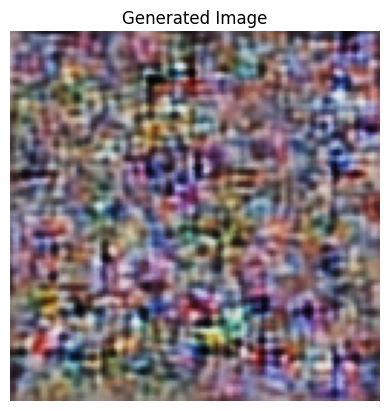

In [37]:
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

encoder.eval()
decoder.eval()
with torch.no_grad():
    z = torch.randn(1, 512, 8, 8).to(device)
    img = decoder(z)
    img = (img.clamp(-1, 1) + 1) / 2  # De-normalize to [0,1]
    img_pil = transforms.ToPILImage()(img.squeeze().cpu())

# Display the image
plt.imshow(img_pil)
plt.axis('off')
plt.title("Generated Image")
plt.show()

Image Generation per class

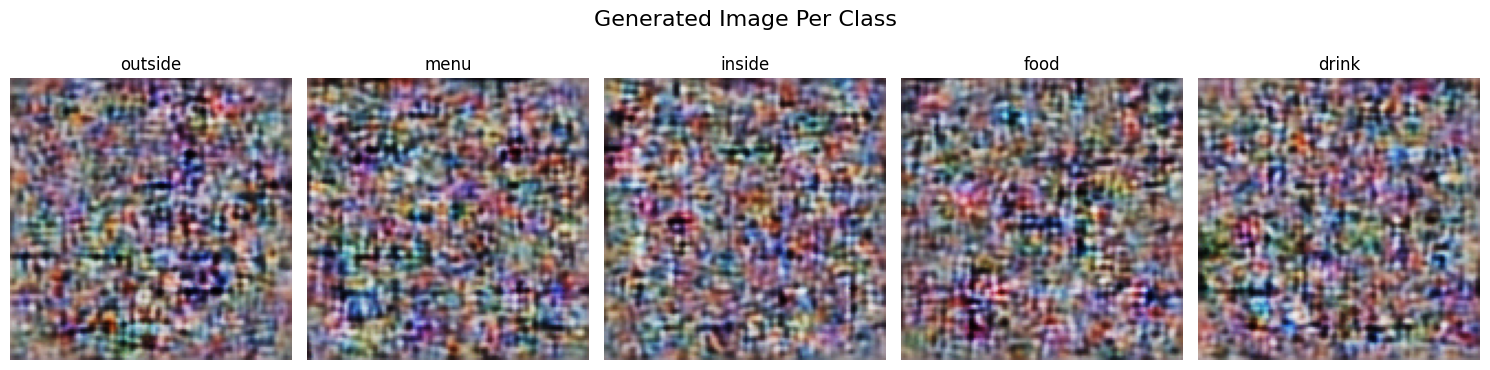

In [39]:
import torch
import matplotlib.pyplot as plt
from torchvision import transforms

# Make sure encoder and decoder are in eval mode
encoder.eval()
decoder.eval()

# Class labels (same order as in your dataset)
class_names = ['outside', 'menu', 'inside', 'food', 'drink']

# Fix transform
to_pil = transforms.ToPILImage()

# Create a plot
fig, axs = plt.subplots(1, 5, figsize=(15, 4))
fig.suptitle("Generated Image Per Class", fontsize=16)

# Generate 1 image per class using fixed random seeds
for i, class_name in enumerate(class_names):
    torch.manual_seed(i)  # Ensure repeatability
    z = torch.randn(1, 512, 8, 8).to(device)

    with torch.no_grad():
        img = decoder(z)
        img = (img.clamp(-1, 1) + 1) / 2  # [0,1] range
        img_pil = to_pil(img.squeeze().cpu())

    axs[i].imshow(img_pil)
    axs[i].axis('off')
    axs[i].set_title(class_name)

plt.tight_layout()
plt.show()

Model Saving

In [40]:
torch.save({
    'epoch': epoch,
    'encoder_state_dict': encoder.state_dict(),
    'decoder_state_dict': decoder.state_dict(),
    'denoiser_state_dict': denoiser.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}, 'ldm_model.pth')

print("Model saved to ldm_model.pth ✅")

Model saved to ldm_model.pth ✅


Model Metrics

In [41]:
!pip install torch-fidelity
!pip install torchmetrics[image]
import torch_fidelity
print("Torch-fidelity is available")

Torch-fidelity is available


In [43]:
import torch
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from torchvision.utils import save_image

# Get a batch of real images
real_imgs, _ = next(iter(dataloader))
real_imgs = real_imgs[:16].to(device)

# Generate fake images
generated_imgs = []
for _ in range(16):
    z = torch.randn(1, 512, 8, 8).to(device)
    with torch.no_grad():
        gen_img = decoder(z)
    gen_img = (gen_img.clamp(-1, 1) + 1) / 2  # Normalize to [0,1]
    generated_imgs.append(gen_img.squeeze(0))

generated_imgs = torch.stack(generated_imgs)

# Save one real and one generated image for visualization (optional)
save_image(real_imgs, "real_samples.png")
save_image(generated_imgs, "generated_samples.png")

# -------- Inception Score --------
# IS expects float32 in [0, 1]
is_metric = InceptionScore(normalize=True).to(device)
inception_score = is_metric(generated_imgs)
print("Inception Score:", inception_score)

# -------- FID Score --------
# FID expects uint8 images in [0, 255]
real_imgs_uint8 = (real_imgs * 255).clamp(0, 255).to(torch.uint8)
generated_imgs_uint8 = (generated_imgs * 255).clamp(0, 255).to(torch.uint8)

fid_metric = FrechetInceptionDistance(feature=2048).to(device)
fid_metric.update(real_imgs_uint8, real=True)
fid_metric.update(generated_imgs_uint8, real=False)
fid_score = fid_metric.compute()
print("FID Score:", fid_score)

Inception Score: (tensor(1.1058, device='cuda:0'), tensor(0.1370, device='cuda:0'))
FID Score: tensor(457.1432, device='cuda:0')


LLM Prompts

*   How to extract data from a zip file dataset?
*   How to visualize and compare generated images for LDM Model for each class?
*   How to evaluate the model’s performance using Inception Score and FID?